In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from datetime import datetime, timezone
from IPython.display import display # For better DataFrame display

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 7) # Default figure size
print("Libraries imported and settings applied.")

Libraries imported and settings applied.


In [3]:
# Define the path to the enriched data file (use absolute path for robustness)
file_path = os.path.abspath("data/sensor_readings_with_weather.parquet")

print(f"Attempting to load data from: {file_path}")

try:
    df_enriched = pl.read_parquet(file_path)
    print(f"Successfully loaded {len(df_enriched)} enriched readings.")
except FileNotFoundError:
    print(f"Error: Enriched data file not found at {file_path}", file=sys.stderr)
    df_enriched = None # Set to None if file not found
except Exception as e:
    print(f"An error occurred loading the data: {e}", file=sys.stderr)
    df_enriched = None

Attempting to load data from: C:\Users\ashle\OneDrive\Documents\GitHub\environmental-sensor-poc\data\sensor_readings_with_weather.parquet
Successfully loaded 14821920 enriched readings.


In [4]:
# Initial Data Exploration
if df_enriched is not None:
    print("Schema:")
    print(df_enriched.schema)

    print("\nSample Data (Head):")
    display(df_enriched.head()) # Use display for better formatting in Jupyter

    print("\nBasic Statistics:")
    display(df_enriched.describe())

    # Check for nulls in key weather columns
    print("\nNull Counts in Weather Columns:")
    weather_cols = ['outdoor_temperature_f', 'outdoor_humidity', 'weather_condition_code', 'weather_timestamp_utc']
    # Ensure weather columns exist before trying to select them
    existing_weather_cols = [col for col in weather_cols if col in df_enriched.columns]
    if existing_weather_cols:
        print(df_enriched.select(existing_weather_cols).null_count())
    else:
        print("Weather columns not found in DataFrame.")

else:
    print("Dataframe not loaded. Cannot perform exploration.")

Schema:
Schema({'SensorReadingUTC': Int64, 'SensorReadingF': Float32, 'SensorID_Coris': Int32, 'SensorName': String, 'DeviceName': String, 'DeviceID_Coris': Int32, 'SensorType': String, 'SensorReadingRh': Float32, 'outdoor_temperature_f': Float64, 'outdoor_humidity': Int64, 'weather_condition_code': Int64, 'weather_timestamp_utc': Int64})

Sample Data (Head):


SensorReadingUTC,SensorReadingF,SensorID_Coris,SensorName,DeviceName,DeviceID_Coris,SensorType,SensorReadingRh,outdoor_temperature_f,outdoor_humidity,weather_condition_code,weather_timestamp_utc
i64,f32,i32,str,str,i32,str,f32,f64,i64,i64,i64
1681825941,-297.220001,21030,"""Cryo tank 1 on ETS 01AB4F (P3)""","""Basement LN2 1 YALE TWhite ETS…",11808,"""Thermocouple""",null,55.0,39,3,1681826400
1681825941,-302.079987,21031,"""Cryo tank 2 on ETS 39FE(P3)""","""Basement LN2 YalePeabody Nov 2…",5671,"""Thermocouple""",null,55.0,39,3,1681826400
1681825941,-118.480003,21032,"""-80 on ETS AB65 (P3)""","""Basement -80 YALE-TWhite ETS …",11809,"""Thermocouple""",null,55.0,39,3,1681826400
1681825941,-276.519989,21038,"""Cryo tank 3 on ETS 39FE(P4)""","""Basement LN2 YalePeabody Nov 2…",5671,"""Thermocouple""",null,55.0,39,3,1681826400
1681825941,66.760002,21373,"""Temp YPM 104_D444""","""Peabody TH-L Mammal Hall D444""",12162,"""Temperature""",null,55.0,39,3,1681826400



Basic Statistics:


statistic,SensorReadingUTC,SensorReadingF,SensorID_Coris,SensorName,DeviceName,DeviceID_Coris,SensorType,SensorReadingRh,outdoor_temperature_f,outdoor_humidity,weather_condition_code,weather_timestamp_utc
str,f64,f64,f64,str,str,f64,str,f64,f64,f64,f64,f64
"""count""",1.482192e7,6.639652e6,1.482192e7,"""14821920""","""14821920""",1.482192e7,"""14821920""",6.140422e6,1.00815e6,1.00815e6,1.00815e6,1.00815e6
"""null_count""",0.0,8.182268e6,0.0,"""0""","""0""",0.0,"""0""",8.681498e6,1.381377e7,1.381377e7,1.381377e7,1.381377e7
"""mean""",1.7134e9,47.005501,25702.297872,null,null,13222.347518,null,49.180222,54.475524,73.335944,10.98965,1.7070e9
"""std""",1.8207e7,81.447258,2965.374406,null,null,1422.51741,null,10.695691,15.179624,19.1097,20.697421,2.6989e7
"""min""",1.6818e9,-313.059998,21030.0,""" RH KGL_21_D0B2""","""Basement -80 YALE-TWhite ETS …",5671.0,"""Humidity""",3.0,10.9,23.0,0.0,1.6818e9
"""25%""",1.6976e9,66.629997,23375.0,null,null,12411.0,null,43.34,43.8,59.0,0.0,1.6846e9
"""50%""",1.7134e9,69.029999,25962.0,null,null,12922.0,null,50.0,54.0,76.0,3.0,1.6885e9
"""75%""",1.7291e9,70.57,28883.0,null,null,14494.0,null,54.799999,67.8,90.0,3.0,1.7407e9
"""max""",1.7449e9,93.470001,30469.0,"""Temp_FLOATER_849259 dead batt""","""x Yale Peabody 8404E5 batt""",15179.0,"""Thermocouple""",100.0,83.5,100.0,73.0,1.7444e9



Null Counts in Weather Columns:
shape: (1, 4)
┌───────────────────────┬──────────────────┬────────────────────────┬───────────────────────┐
│ outdoor_temperature_f ┆ outdoor_humidity ┆ weather_condition_code ┆ weather_timestamp_utc │
│ ---                   ┆ ---              ┆ ---                    ┆ ---                   │
│ u32                   ┆ u32              ┆ u32                    ┆ u32                   │
╞═══════════════════════╪══════════════════╪════════════════════════╪═══════════════════════╡
│ 13813770              ┆ 13813770         ┆ 13813770               ┆ 13813770              │
└───────────────────────┴──────────────────┴────────────────────────┴───────────────────────┘


In [5]:
# Data Preprocessing for Analysis
df_analysis = None # Initialize df_analysis
if df_enriched is not None:
    # Use try-except blocks for robustness in case columns are missing/null
    try:
        df_analysis_temp = df_enriched.with_columns([
            # Convert SensorReadingUTC (Unix timestamp) to Datetime (UTC)
            pl.from_epoch(pl.col("SensorReadingUTC"), time_unit="s").dt.replace_time_zone("UTC").alias("datetime_utc")
        ])

        # Convert weather_timestamp_utc if it exists
        if "weather_timestamp_utc" in df_analysis_temp.columns:
             df_analysis_temp = df_analysis_temp.with_columns([
                 pl.when(pl.col("weather_timestamp_utc").is_not_null())
                   .then(pl.from_epoch(pl.col("weather_timestamp_utc"), time_unit="s").dt.replace_time_zone("UTC"))
                   .otherwise(None)
                   .alias("weather_datetime_utc")
             ])
        else:
             # Create null column if weather data wasn't joined properly or is missing
             df_analysis_temp = df_analysis_temp.with_columns(pl.lit(None).cast(pl.Datetime(time_unit="us", time_zone="UTC")).alias("weather_datetime_utc"))

        # Convert to local time (e.g., US/Eastern) for plotting if desired
        # Ensure the input columns for conversion exist and are not null before converting
        df_analysis = df_analysis_temp.with_columns([
            pl.col("datetime_utc").dt.convert_time_zone("America/New_York").alias("datetime_local"),
            pl.when(pl.col("weather_datetime_utc").is_not_null())
              .then(pl.col("weather_datetime_utc").dt.convert_time_zone("America/New_York"))
              .otherwise(None)
              .alias("weather_datetime_local")
        ])

        print("Added datetime columns. Sample:")
        display(df_analysis.select(["datetime_utc", "datetime_local", "weather_datetime_utc", "weather_datetime_local"]).head())

    except Exception as e:
        print(f"Error during datetime preprocessing: {e}", file=sys.stderr)
        # df_analysis remains None if preprocessing fails

else:
    print("Dataframe not loaded. Cannot preprocess.")

# Keep a reference to the analysis df for subsequent cells
if 'df_analysis' not in locals():
    df_analysis = None


Added datetime columns. Sample:


datetime_utc,datetime_local,weather_datetime_utc,weather_datetime_local
"datetime[μs, UTC]","datetime[μs, America/New_York]","datetime[μs, UTC]","datetime[μs, America/New_York]"
2023-04-18 13:52:21 UTC,2023-04-18 09:52:21 EDT,2023-04-18 14:00:00 UTC,2023-04-18 10:00:00 EDT
2023-04-18 13:52:21 UTC,2023-04-18 09:52:21 EDT,2023-04-18 14:00:00 UTC,2023-04-18 10:00:00 EDT
2023-04-18 13:52:21 UTC,2023-04-18 09:52:21 EDT,2023-04-18 14:00:00 UTC,2023-04-18 10:00:00 EDT
2023-04-18 13:52:21 UTC,2023-04-18 09:52:21 EDT,2023-04-18 14:00:00 UTC,2023-04-18 10:00:00 EDT
2023-04-18 13:52:21 UTC,2023-04-18 09:52:21 EDT,2023-04-18 14:00:00 UTC,2023-04-18 10:00:00 EDT


Processing 381440 valid/finite temperature readings...
Plotting sample (38144 points) for Indoor vs. Outdoor Temperature...


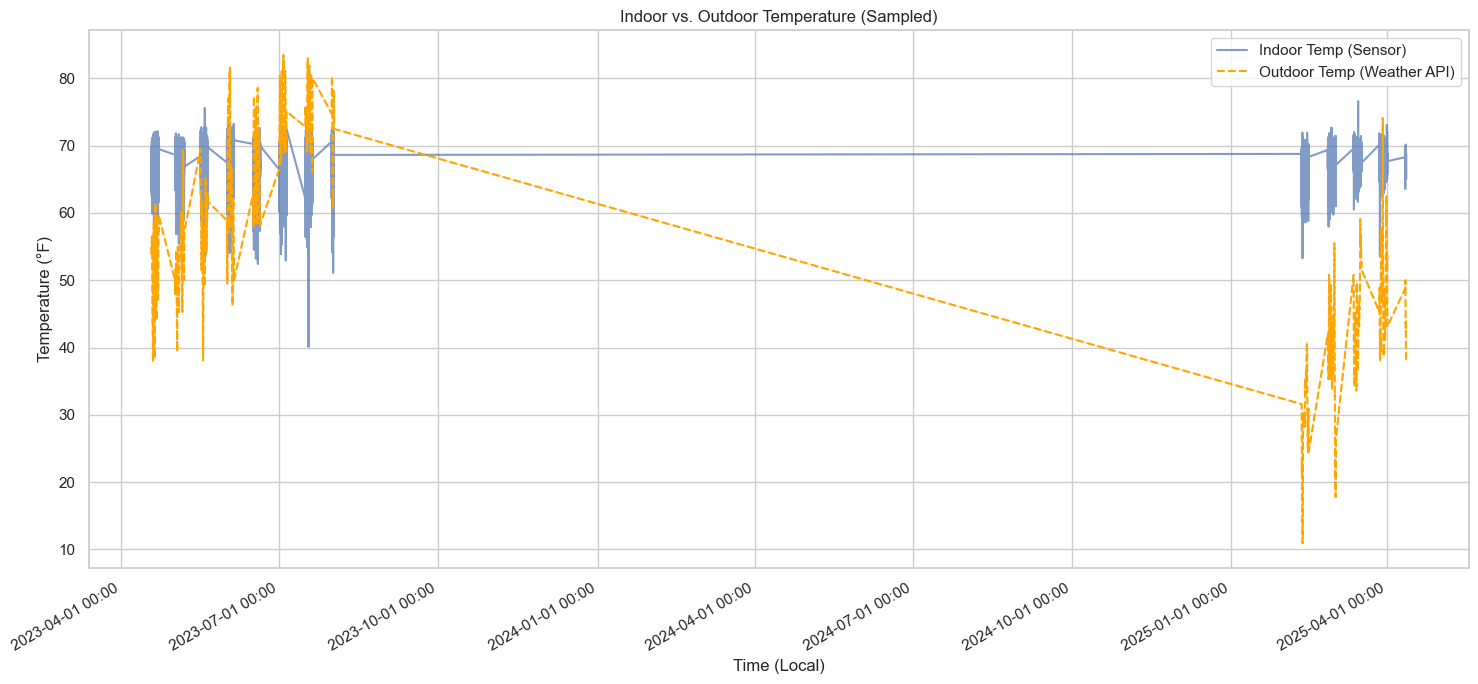

Calculating and plotting hourly averages...


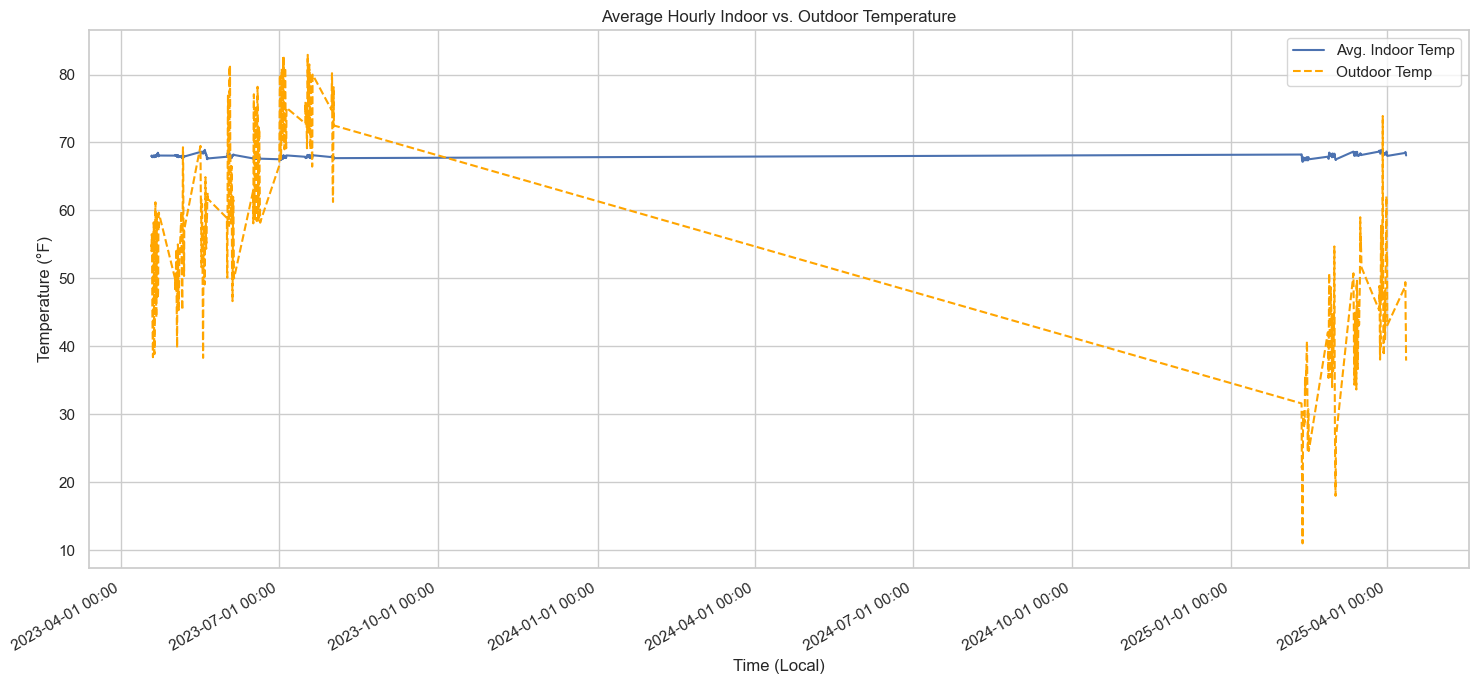

Failed to convert datetime to numeric timestamp (Previous message - code updated).


In [10]:
# Example Analysis: Indoor vs. Outdoor Temperature
import matplotlib.dates as mdates # Still needed for formatting
import numpy as np
import pandas as pd # Ensure pandas is imported

if df_analysis is not None:
    # Check if required columns exist
    required_cols = ["SensorType", "SensorReadingF", "outdoor_temperature_f", "datetime_local"]
    if all(col in df_analysis.columns for col in required_cols):

        # Filter data (same as before)
        lower_temp_bound = 0
        df_temp = df_analysis.filter(
            (pl.col("SensorType") == "Temperature") &
            (pl.col("SensorReadingF").is_not_null()) &
            (pl.col("SensorReadingF").is_finite()) &
            (pl.col("outdoor_temperature_f").is_not_null()) &
            (pl.col("outdoor_temperature_f").is_finite()) &
            (pl.col("SensorReadingF") >= lower_temp_bound)
        ).sort("datetime_local") # Sorting helps chronological plotting

        if not df_temp.is_empty():
            print(f"Processing {len(df_temp)} valid/finite temperature readings...")

            # Option 1: Simple line plot
            sample_fraction = 0.1 if len(df_temp) > 50000 else 1.0
            # Select columns needed for plot
            df_temp_sample = df_temp.sample(fraction=sample_fraction).select(
                ["datetime_local", "SensorReadingF", "outdoor_temperature_f"]
            )
            # Convert to Pandas, then explicitly convert datetime column
            df_temp_pd = df_temp_sample.to_pandas(use_pyarrow_extension_array=True)
            # Ensure 'datetime_local' is a proper datetime type recognizable by matplotlib/seaborn
            df_temp_pd['datetime_local'] = pd.to_datetime(df_temp_pd['datetime_local'])


            print(f"Plotting sample ({len(df_temp_pd)} points) for Indoor vs. Outdoor Temperature...")
            try:
                fig1, ax1 = plt.subplots()
                # Pass the datetime column directly
                sns.lineplot(data=df_temp_pd, x="datetime_local", y="SensorReadingF", label="Indoor Temp (Sensor)", alpha=0.7, errorbar=None, ax=ax1)
                sns.lineplot(data=df_temp_pd, x="datetime_local", y="outdoor_temperature_f", label="Outdoor Temp (Weather API)", color='orange', linestyle='--', ax=ax1)

                # Format x-axis to show dates
                ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz='America/New_York'))
                fig1.autofmt_xdate() # Auto format date labels

                ax1.set_title("Indoor vs. Outdoor Temperature (Sampled)")
                ax1.set_ylabel("Temperature (°F)")
                ax1.set_xlabel("Time (Local)")
                ax1.legend()
                plt.tight_layout()
                plt.show()
            except Exception as plot_e:
                 print(f"Error during first temperature plot: {plot_e}")


            # Option 2: Plotting average hourly indoor temperature vs outdoor
            print("Calculating and plotting hourly averages...")
            try:
                # Group by original datetime truncated to hour
                df_temp_avg = df_temp.group_by(pl.col("datetime_local").dt.truncate("1h")).agg([
                    pl.mean("SensorReadingF").alias("avg_indoor_temp"),
                    pl.mean("outdoor_temperature_f").alias("outdoor_temp")
                ]).sort("datetime_local") # Sort by original datetime

                if not df_temp_avg.is_empty():
                    df_temp_avg = df_temp_avg.filter(
                        pl.col("avg_indoor_temp").is_finite() & pl.col("outdoor_temp").is_finite()
                    )
                    if not df_temp_avg.is_empty():
                        # Convert aggregated data to Pandas
                        df_temp_avg_pd = df_temp_avg.to_pandas(use_pyarrow_extension_array=True)
                        # Ensure 'datetime_local' is a proper datetime type
                        df_temp_avg_pd['datetime_local'] = pd.to_datetime(df_temp_avg_pd['datetime_local'])

                        fig2, ax2 = plt.subplots()
                        # Pass the datetime column directly
                        sns.lineplot(data=df_temp_avg_pd, x="datetime_local", y="avg_indoor_temp", label="Avg. Indoor Temp", ax=ax2)
                        sns.lineplot(data=df_temp_avg_pd, x="datetime_local", y="outdoor_temp", label="Outdoor Temp", color='orange', linestyle='--', ax=ax2)

                        # Format x-axis
                        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz='America/New_York'))
                        fig2.autofmt_xdate()

                        ax2.set_title("Average Hourly Indoor vs. Outdoor Temperature")
                        ax2.set_ylabel("Temperature (°F)")
                        ax2.set_xlabel("Time (Local)")
                        ax2.legend()
                        plt.tight_layout()
                        plt.show()
                    else:
                        print("No finite data remaining after hourly aggregation for temperature.")
                else:
                    print("No data remaining after hourly aggregation for temperature.")
            except Exception as agg_e:
                 print(f"Could not calculate or plot hourly average temperature: {agg_e}")

            # REMOVED UNNECESSARY ELSE BLOCK HERE

        else:
            print("No valid/finite temperature data found for processing (after filtering nulls and outliers).")
    else:
        print("Missing required columns for temperature analysis.")
else:
    print("Dataframe `df_analysis` not available. Cannot perform analysis.")


Processing 372550 valid/finite humidity readings...


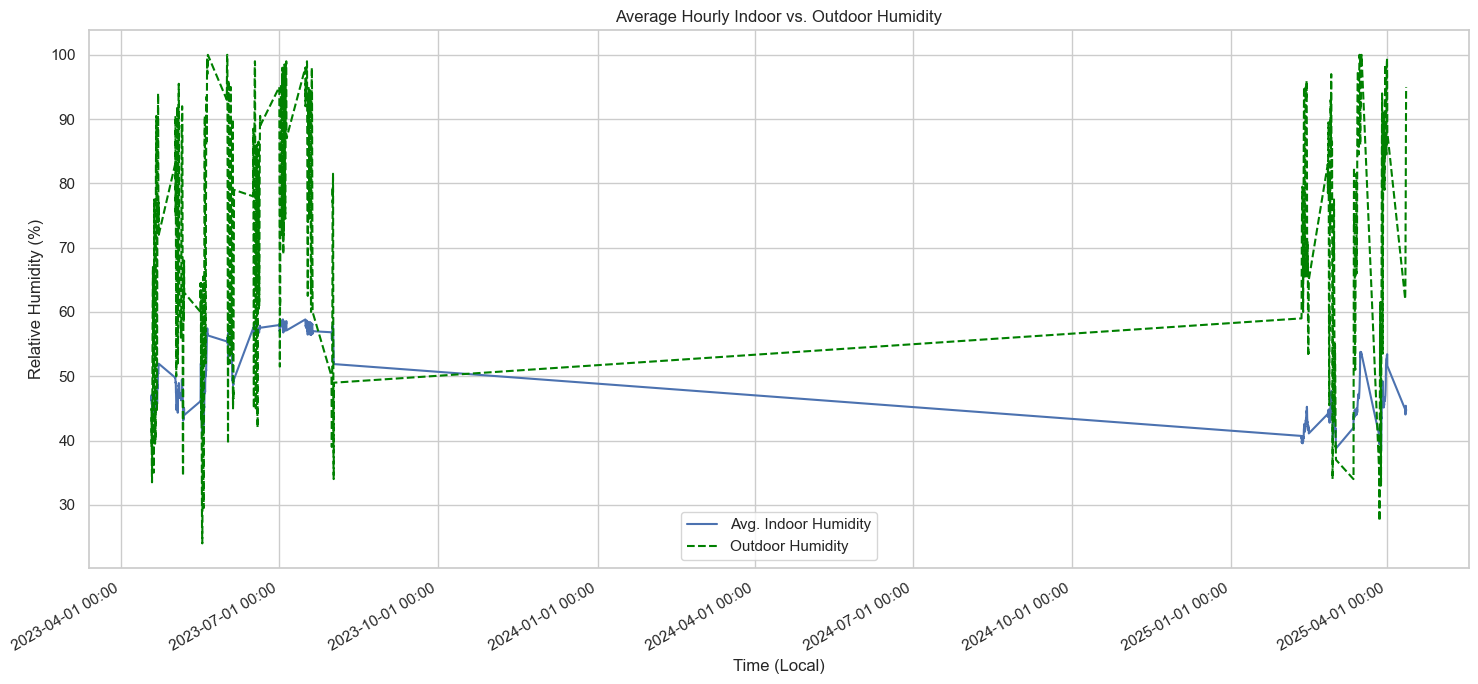

In [11]:
# Example Analysis: Indoor vs. Outdoor Humidity
if df_analysis is not None:
    required_cols = ["SensorType", "SensorReadingRh", "outdoor_humidity", "datetime_local"]
    if all(col in df_analysis.columns for col in required_cols):
        # Filter for Humidity sensors and valid/finite readings
        df_humidity = df_analysis.filter(
            (pl.col("SensorType") == "Humidity") &
            (pl.col("SensorReadingRh").is_not_null()) &
            (pl.col("SensorReadingRh").is_finite()) & # Ensure indoor humidity is finite
            (pl.col("outdoor_humidity").is_not_null()) &
            (pl.col("outdoor_humidity").is_finite()) # Ensure outdoor humidity is finite
        ).sort("datetime_local")

        if not df_humidity.is_empty():
            print(f"Processing {len(df_humidity)} valid/finite humidity readings...")

            # Plotting average hourly humidity
            try:
                df_hum_avg = df_humidity.group_by(pl.col("datetime_local").dt.truncate("1h")).agg([
                    pl.mean("SensorReadingRh").alias("avg_indoor_humidity"),
                    pl.mean("outdoor_humidity").alias("outdoor_humidity")
                ]).sort("datetime_local")

                if not df_hum_avg.is_empty():
                     # Filter again after aggregation
                    df_hum_avg = df_hum_avg.filter(
                        pl.col("avg_indoor_humidity").is_finite() & pl.col("outdoor_humidity").is_finite()
                    )
                    if not df_hum_avg.is_empty():
                        # Convert to Pandas and ensure datetime type
                        df_hum_avg_pd = df_hum_avg.to_pandas(use_pyarrow_extension_array=True)
                        df_hum_avg_pd['datetime_local'] = pd.to_datetime(df_hum_avg_pd['datetime_local'])

                        plt.figure()
                        sns.lineplot(data=df_hum_avg_pd, x="datetime_local", y="avg_indoor_humidity", label="Avg. Indoor Humidity")
                        sns.lineplot(data=df_hum_avg_pd, x="datetime_local", y="outdoor_humidity", label="Outdoor Humidity", color='green', linestyle='--')

                        # Format x-axis
                        plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M', tz='America/New_York'))
                        plt.gcf().autofmt_xdate()

                        plt.title("Average Hourly Indoor vs. Outdoor Humidity")
                        plt.ylabel("Relative Humidity (%)")
                        plt.xlabel("Time (Local)")
                        plt.legend()
                        plt.tight_layout()
                        plt.show()
                    else:
                         print("No finite data remaining after hourly aggregation for humidity.")
                else:
                    print("No data remaining after hourly aggregation for humidity.")
            except Exception as agg_e:
                print(f"Could not calculate or plot hourly average humidity: {agg_e}")

        else:
            print("No valid/finite humidity data found for plotting.")
    else:
        print("Missing required columns for humidity analysis.")
else:
    print("Dataframe `df_analysis` not available. Cannot perform analysis.")

Mapping weather codes to descriptions...
Weather descriptions mapped.
Generating Indoor Temp vs. Weather Condition boxplot...


C:\Users\ashle\AppData\Local\Temp\ipykernel_32924\4057287292.py:29: DeprecationWarning: The `default` parameter for `replace` is deprecated. Use `replace_strict` instead to set a default while replacing values.
  pl.col("weather_condition_code").cast(pl.Int64).replace( # Cast to Int64 just in case
C:\Users\ashle\AppData\Local\Temp\ipykernel_32924\4057287292.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_temp_weather_pd, x="weather_description", y="SensorReadingF", order=order, palette="coolwarm")


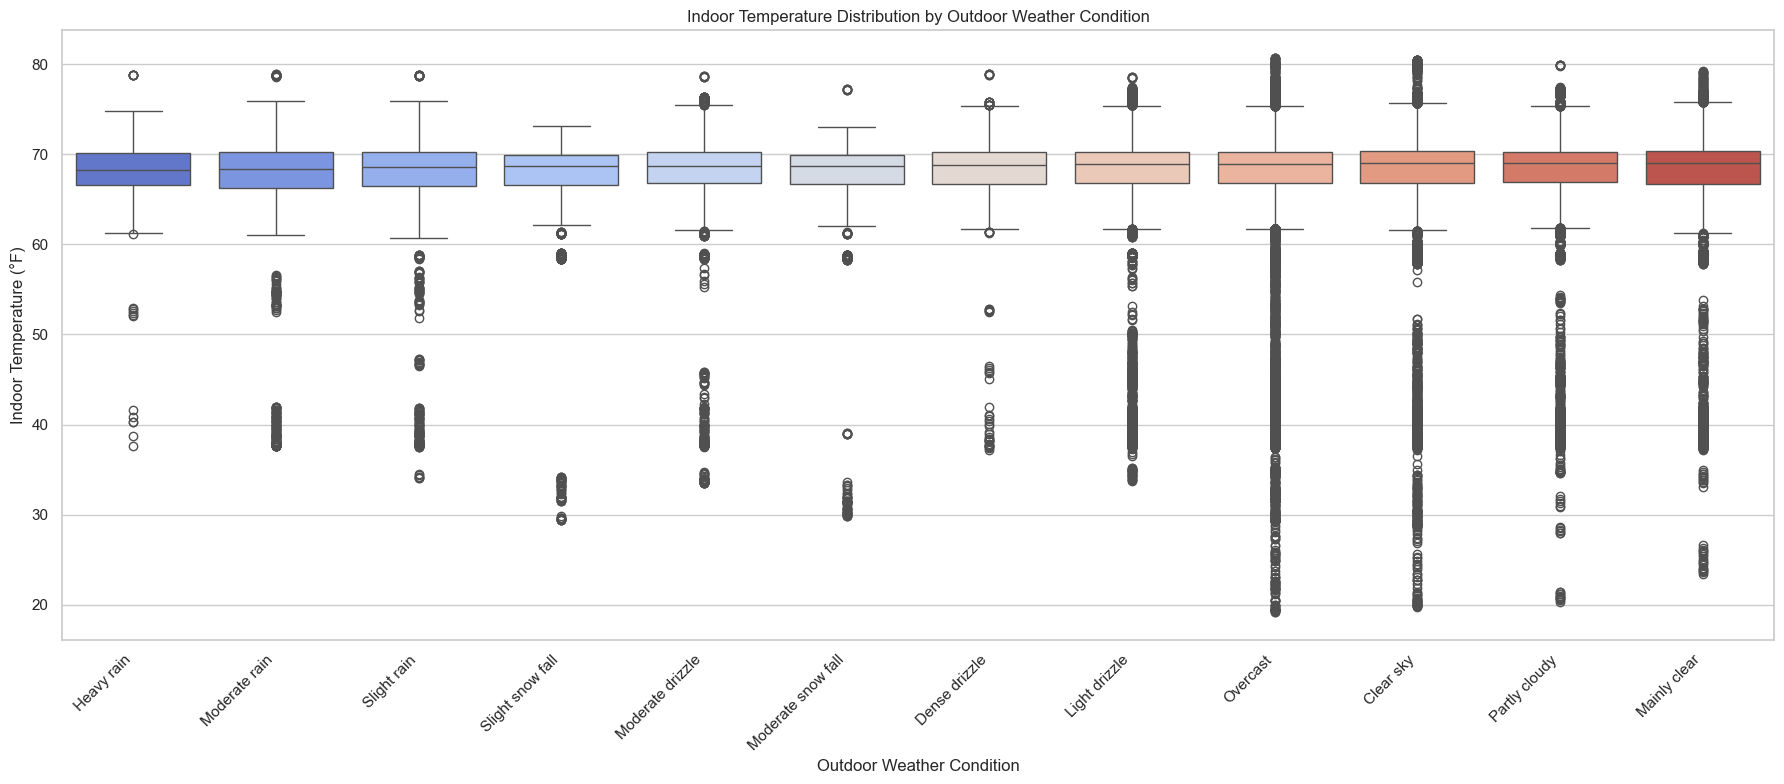

Generating Indoor Humidity vs. Weather Condition boxplot...


C:\Users\ashle\AppData\Local\Temp\ipykernel_32924\4057287292.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hum_weather_pd, x="weather_description", y="SensorReadingRh", order=order, palette="viridis")


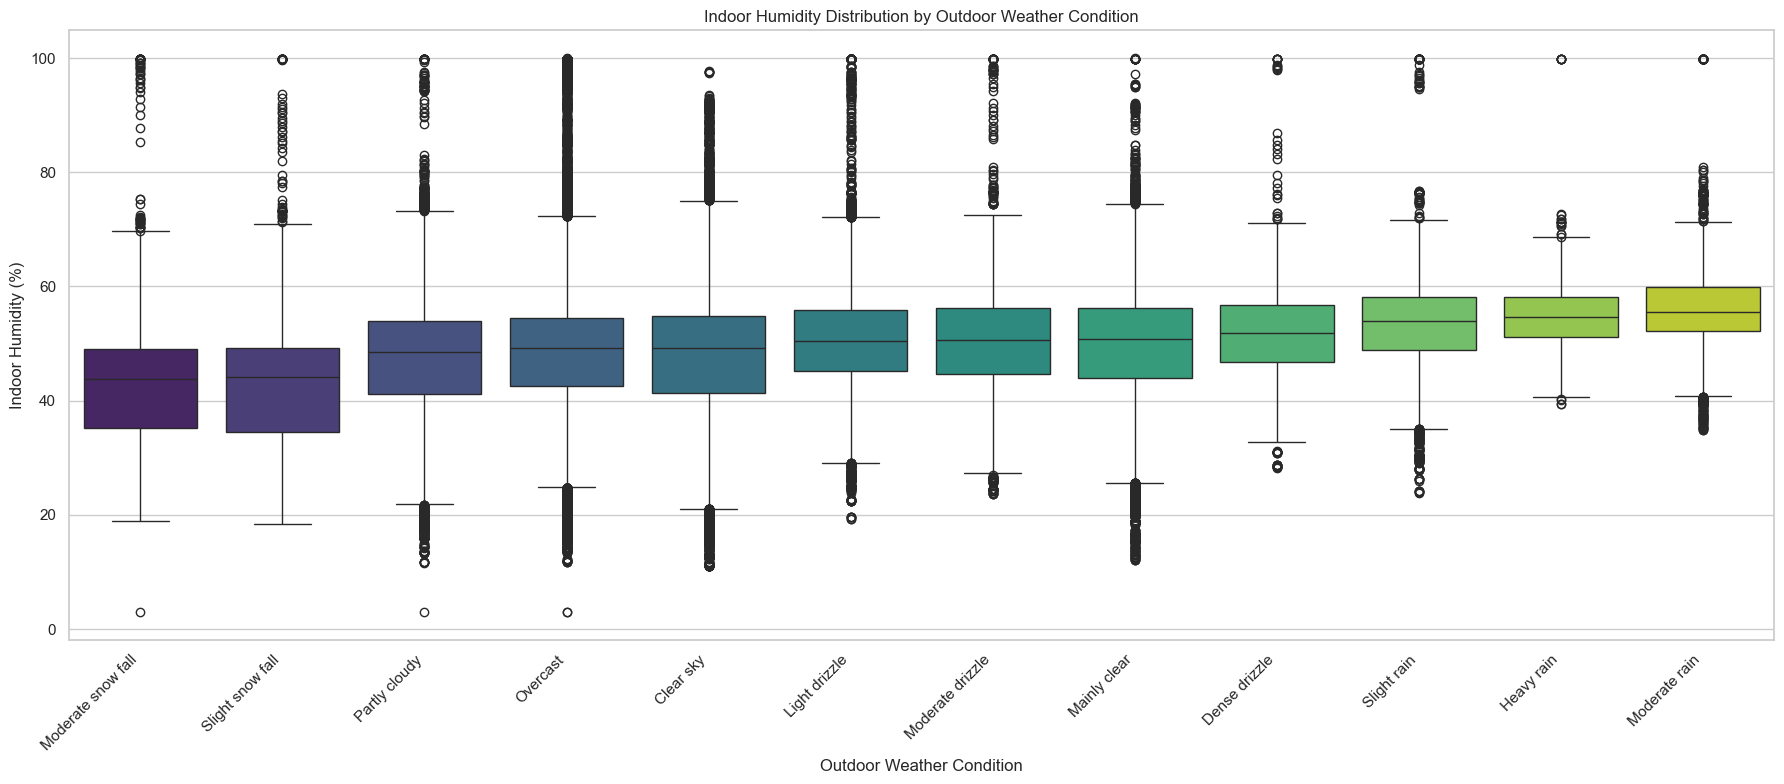

In [12]:
# Example Analysis: Sensor Readings by Weather Condition
if df_analysis is not None:
    if "weather_condition_code" in df_analysis.columns:
        # WMO Weather interpretation codes (WW) from Open-Meteo Documentation
        # (Simplified mapping for demonstration)
        wmo_codes = {
            0: 'Clear sky',
            1: 'Mainly clear', 2: 'Partly cloudy', 3: 'Overcast',
            45: 'Fog', 48: 'Depositing rime fog',
            51: 'Light drizzle', 53: 'Moderate drizzle', 55: 'Dense drizzle',
            56: 'Light freezing drizzle', 57: 'Dense freezing drizzle',
            61: 'Slight rain', 63: 'Moderate rain', 65: 'Heavy rain',
            66: 'Light freezing rain', 67: 'Heavy freezing rain',
            71: 'Slight snow fall', 73: 'Moderate snow fall', 75: 'Heavy snow fall',
            77: 'Snow grains',
            80: 'Slight rain showers', 81: 'Moderate rain showers', 82: 'Violent rain showers',
            85: 'Slight snow showers', 86: 'Heavy snow showers',
            95: 'Thunderstorm', 96: 'Thunderstorm slight hail', 99: 'Thunderstorm heavy hail'
            # Note: Add more codes if present in your data
        }

        print("Mapping weather codes to descriptions...")
        try:
            # Create the weather description column
            # Ensure the column to be replaced is Int type for mapping keys
            df_weather_cond = df_analysis.filter(
                pl.col("weather_condition_code").is_not_null()
            ).with_columns([
                pl.col("weather_condition_code").cast(pl.Int64).replace( # Cast to Int64 just in case
                    wmo_codes, default="Unknown"
                ).alias("weather_description")
            ])
            print("Weather descriptions mapped.")

            # -- Plot Indoor Temperature by Weather Condition --
            if "SensorType" in df_weather_cond.columns and "SensorReadingF" in df_weather_cond.columns:
                df_temp_weather = df_weather_cond.filter(
                    (pl.col("SensorType") == "Temperature") &
                    (pl.col("SensorReadingF").is_finite()) & # Added finite check here too
                    (pl.col("SensorReadingF") >= lower_temp_bound) # Use bound from previous cell
                 )
                if not df_temp_weather.is_empty():
                    print("Generating Indoor Temp vs. Weather Condition boxplot...")
                    plt.figure(figsize=(18, 8)) # Wider figure for potentially many categories
                    # Using seaborn boxplot
                    df_temp_weather_pd = df_temp_weather.select(["weather_description", "SensorReadingF"]).to_pandas(use_pyarrow_extension_array=True)
                    # Order boxes by median temperature
                    order = df_temp_weather_pd.groupby("weather_description")["SensorReadingF"].median().sort_values().index.to_list()
                    sns.boxplot(data=df_temp_weather_pd, x="weather_description", y="SensorReadingF", order=order, palette="coolwarm")
                    plt.title("Indoor Temperature Distribution by Outdoor Weather Condition")
                    plt.ylabel("Indoor Temperature (°F)")
                    plt.xlabel("Outdoor Weather Condition")
                    plt.xticks(rotation=45, ha='right')
                    plt.tight_layout()
                    plt.show()
                else:
                    print("No valid/finite temperature data with weather conditions found.")
            else:
                 print("Missing SensorType or SensorReadingF column for temp/weather analysis.")

            # -- Plot Indoor Humidity by Weather Condition --
            if "SensorType" in df_weather_cond.columns and "SensorReadingRh" in df_weather_cond.columns:
                df_hum_weather = df_weather_cond.filter(
                     (pl.col("SensorType") == "Humidity") &
                     (pl.col("SensorReadingRh").is_finite()) # Added finite check
                )
                if not df_hum_weather.is_empty():
                    print("Generating Indoor Humidity vs. Weather Condition boxplot...")
                    plt.figure(figsize=(18, 8))
                    df_hum_weather_pd = df_hum_weather.select(["weather_description", "SensorReadingRh"]).to_pandas(use_pyarrow_extension_array=True)
                    # Order boxes by median humidity
                    order = df_hum_weather_pd.groupby("weather_description")["SensorReadingRh"].median().sort_values().index.to_list()
                    sns.boxplot(data=df_hum_weather_pd, x="weather_description", y="SensorReadingRh", order=order, palette="viridis")
                    plt.title("Indoor Humidity Distribution by Outdoor Weather Condition")
                    plt.ylabel("Indoor Humidity (%)")
                    plt.xlabel("Outdoor Weather Condition")
                    plt.xticks(rotation=45, ha='right')
                    plt.tight_layout()
                    plt.show()
                else:
                    print("No valid/finite humidity data with weather conditions found.")
            else:
                print("Missing SensorType or SensorReadingRh column for humidity/weather analysis.")
        except Exception as e:
            print(f"Error during weather condition analysis: {e}", file=sys.stderr)

    else:
        print("weather_condition_code column not found. Cannot perform analysis by weather condition.")
else:
    print("Dataframe `df_analysis` not available. Cannot perform analysis.")